In [1]:
import os
import shutil
import zipfile
import pandas as pd
from google.colab import files

# Путь к исходному файлу (предполагается, что вы загрузили kaggle.json)
source_path = '/content/kaggle.json'  # или другой путь, где находится файл
destination_dir = '/root/.kaggle'
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    # Устанавливаем права доступа
    os.chmod(destination_path, 0o600)
else:
    # Загружаем файл, если его нет
    uploaded = files.upload()
    # После загрузки переместите файл в нужную директорию
    if 'kaggle.json' in uploaded:
        shutil.move('kaggle.json', destination_path)
        os.chmod(destination_path, 0o600)

# Теперь можно использовать Kaggle API для загрузки датасета
!kaggle datasets download -d nathania09/diabetes-risk

# Распакуйте скачанный архив:
with zipfile.ZipFile('diabetes-risk.zip', 'r') as zip_ref:
    zip_ref.extractall('diabetes-risk')

# Показать файлы в директории
print("Файлы в директории:")
print(os.listdir('diabetes-risk'))

# ИСПРАВЛЕНО: используем правильное имя файла (с подчеркиванием)
df = pd.read_csv('diabetes-risk/diabetes_risk.csv')

# Просматриваем первые несколько строк датасета
print("\nПервые 5 строк датасета:")
print(df.head())

# Получаем общую информацию о датасете
print("\nИнформация о датасете:")
print(df.info())

# Выводим статистические данные о числовых столбцах
print("\nСтатистическое описание:")
print(df.describe())

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nathania09/diabetes-risk
License(s): unknown
  0% 0.00/629 [00:00<?, ?B/s]
100% 629/629 [00:00<00:00, 1.91MB/s]
Файлы в директории:
['diabetes_risk.csv']

Первые 5 строк датасета:
   age  glucose_level  blood_pressure  insulin   bmi  exercise_hours  \
0   25             85             120      100  22.5               2   
1   45            130             140      250  29.8               0   
2   35             95             135      200  26.4               1   
3   28             80             115       90  23.1               3   
4   50            140             145      300  32.1               0   

  diabetes_risk  
0           low  
1          high  
2        medium  
3           low  
4          high  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------

In [2]:
#Посмотрим какие файлы появились
import os
print ("Содержимое папки после распаковки:")
print (os.listdir('.'))

Содержимое папки после распаковки:
['.config', 'diabetes-risk', 'diabetes-risk.zip', 'sample_data']


In [5]:
from sqlite3.dbapi2 import Cursor
import sqlite3

#соединяемся с базой данных
conn = sqlite3.connect('diabetes.db')
cursor = conn.cursor()
print ("База данных создана подключена")

База данных создана подключена


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from genericpath import exists


In [7]:
#создание таблицы
cursor= conn.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS diabetes_data (user_id INTEGER PRIMARY KEY AUTOINCREMENT,
Patient_ID INTEGER,
age Integer,
bmi REAL,
blood_pressure INTEGER,
fasting_glucose_level Integer,
insulin_leveL Real,
cholesterol_level INTEGER,
daily_calorie_intake Integer,
family_history_diabetes TEXT,
sleep_hours REAL,
stress_level INTEGER,
diabetes_risk_score REAL,
diabetes_risk_category TEXT
)
''')
conn. commit()
print("Таблица создана проверена успешно!")


Таблица создана проверена успешно!


In [8]:
#загрузка данных

df_selected = pd.read_sql_query("""
SELECT Patient_ID', 'age', 'bmi', 'blood_pressure', 'fasting_glucose_level', 'insulin_level', 'cholesterol_level', 'daily_calorie_intake', 'family_history_diabetes', 'sleep_hours','stress_level', 'diabetes_risk_score', 'diabetes_risk_category'
FROM diabetes_data
""",conn)
print (df_selected.head())

DatabaseError: Execution failed on sql '
SELECT Patient_ID', 'age', 'bmi', 'blood_pressure', 'fasting_glucose_level', 'insulin_level', 'cholesterol_level', 'daily_calorie_intake', 'family_history_diabetes', 'sleep_hours','stress_level', 'diabetes_risk_score', 'diabetes_risk_category'
FROM diabetes_data
': near "age": syntax error

In [9]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Создание базы данных и подключение
conn = sqlite3.connect('diabetes_analysis.db')
cursor = conn.cursor()

# Создание таблицы (улучшенная версия из предыдущего файла)
cursor.execute('''
CREATE TABLE IF NOT EXISTS diabetes_data (
    patient_id INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER,
    gender TEXT,
    BMI FLOAT,
    blood_pressure INTEGER,
    fasting_glucose_level INTEGER,
    insulin_level REAL,
    cholesterol_level INTEGER,
    daily_calorie_intake INTEGER,
    family_history_diabetes TEXT,
    sleep_hours REAL,
    stress_level INTEGER,
    physical_activity_hours REAL,
    smoking_status TEXT,
    diabetes_risk_score REAL,
    diabetes_risk_category TEXT,
    examination_date DATE
)
''')

# Генерация синтетических данных (500 записей)
np.random.seed(42)

def generate_diabetes_data(n_records=500):
    data = []

    for i in range(n_records):
        # Возраст (20-80 лет)
        age = np.random.randint(20, 81)

        # Пол
        gender = np.random.choice(['Male', 'Female'], p=[0.48, 0.52])

        # BMI (15-45)
        BMI = round(np.random.normal(28, 5), 1)
        BMI = max(15, min(45, BMI))

        # Давление (систолическое)
        blood_pressure = np.random.randint(90, 180)

        # Уровень глюкозы (70-250)
        fasting_glucose = np.random.randint(70, 251)

        # Инсулин (2-300)
        insulin = round(np.random.uniform(2, 300), 1)

        # Холестерин (150-300)
        cholesterol = np.random.randint(150, 301)

        # Калории (1500-3500)
        calories = np.random.randint(1500, 3501)

        # Семейная история
        family_history = np.random.choice(['Yes', 'No'], p=[0.3, 0.7])

        # Сон (4-10 часов)
        sleep = round(np.random.uniform(4, 10), 1)

        # Стресс (1-10)
        stress = np.random.randint(1, 11)

        # Физическая активность (0-10 часов)
        activity = round(np.random.uniform(0, 10), 1)

        # Курение
        smoking = np.random.choice(['Never', 'Former', 'Current'], p=[0.6, 0.2, 0.2])

        # Расчет риска диабета (упрощенная формула)
        risk_score = (
            (age - 20) / 60 * 0.2 +
            (BMI - 15) / 30 * 0.25 +
            (fasting_glucose - 70) / 180 * 0.3 +
            (1 if family_history == 'Yes' else 0) * 0.15 +
            (stress / 10) * 0.1
        )
        risk_score = min(1, max(0, risk_score))

        # Категория риска
        if risk_score < 0.3:
            risk_category = 'Low'
        elif risk_score < 0.5:
            risk_category = 'Moderate'
        elif risk_score < 0.7:
            risk_category = 'High'
        else:
            risk_category = 'Very High'

        # Дата обследования (случайная дата за последние 2 года)
        days_ago = np.random.randint(0, 730)
        exam_date = (datetime.now() - timedelta(days=days_ago)).strftime('%Y-%m-%d')

        data.append([
            age, gender, BMI, blood_pressure, fasting_glucose,
            insulin, cholesterol, calories, family_history,
            sleep, stress, activity, smoking, risk_score,
            risk_category, exam_date
        ])

    return data

# Генерация данных
synthetic_data = generate_diabetes_data(500)

# Вставка данных в таблицу
cursor.executemany('''
INSERT INTO diabetes_data (
    age, gender, BMI, blood_pressure, fasting_glucose_level,
    insulin_level, cholesterol_level, daily_calorie_intake,
    family_history_diabetes, sleep_hours, stress_level,
    physical_activity_hours, smoking_status, diabetes_risk_score,
    diabetes_risk_category, examination_date
) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
''', synthetic_data)

conn.commit()
print("Данные успешно загружены в базу данных!")

Данные успешно загружены в базу данных!


In [11]:
# Отберем пациентов с высоким риском (возраст > 50, высокое давление)
query1 = '''
SELECT patient_id, age, BMI, blood_pressure, diabetes_risk_category
FROM diabetes_data
WHERE age > 50 AND blood_pressure > 140
ORDER BY diabetes_risk_score DESC
LIMIT 20;
'''

high_risk_patients = pd.read_sql_query(query1, conn)
print("Пациенты с высоким риском:")
print(high_risk_patients)



Пациенты с высоким риском:
    patient_id  age   BMI  blood_pressure diabetes_risk_category
0          274   70  26.9             160              Very High
1          305   67  40.1             162              Very High
2          199   73  24.3             162              Very High
3          427   78  30.6             142              Very High
4          281   57  34.6             150              Very High
5           50   76  31.2             169              Very High
6          371   54  34.4             166              Very High
7          124   60  26.7             164                   High
8          167   69  26.6             173                   High
9          468   74  32.6             155                   High
10         354   77  29.1             143                   High
11         413   80  26.2             169                   High
12         420   61  23.5             174                   High
13          67   65  26.7             149                   Hig

In [12]:
# Отфильтруем молодых пациентов с избыточным весом и семейной историей
query2 = '''
SELECT patient_id, age, BMI, family_history_diabetes, diabetes_risk_score
FROM diabetes_data
WHERE age < 30 AND BMI > 30 AND family_history_diabetes = 'Yes'
ORDER BY diabetes_risk_score DESC;
'''

young_high_risk = pd.read_sql_query(query2, conn)
print(f"\nМолодые пациенты с риском: {len(young_high_risk)} человек")
print(young_high_risk.head())


Молодые пациенты с риском: 8 человек
   patient_id  age   BMI family_history_diabetes  diabetes_risk_score
0         338   26  36.8                     Yes             0.683333
1         126   25  36.8                     Yes             0.671667
2          70   26  35.6                     Yes             0.561667
3         340   29  32.5                     Yes             0.512500
4         400   22  36.5                     Yes             0.489167


In [14]:
# Рассчитаем общую статистику по всем пациентам
query_stats = '''
SELECT
    COUNT(*) AS total_patients,
    AVG(age) AS avg_age,
    MIN(age) AS min_age,
    MAX(age) AS max_age,
    AVG(BMI) AS avg_bmi,
    AVG(blood_pressure) AS avg_blood_pressure,
    AVG(fasting_glucose_level) AS avg_glucose,
    AVG(diabetes_risk_score) AS avg_risk_score,
    SUM(CASE WHEN family_history_diabetes = 'Yes' THEN 1 ELSE 0 END) AS family_history_count,
    SUM(CASE WHEN smoking_status = 'Current' THEN 1 ELSE 0 END) AS current_smokers
FROM diabetes_data;
'''

stats_df = pd.read_sql_query(query_stats, conn)
print("\nОбщая статистика:")
print(stats_df)




Общая статистика:
   total_patients  avg_age  min_age  max_age  avg_bmi  avg_blood_pressure  \
0             500   49.156       20       80  27.9614             132.826   

   avg_glucose  avg_risk_score  family_history_count  current_smokers  
0      158.404        0.452638                   150              104  


In [15]:
# Выберем статистику по группам риска
query_by_risk = '''
SELECT
    diabetes_risk_category,
    COUNT(*) AS patient_count,
    AVG(age) AS avg_age,
    AVG(BMI) AS avg_bmi,
    AVG(blood_pressure) AS avg_bp,
    AVG(fasting_glucose_level) AS avg_glucose,
    AVG(physical_activity_hours) AS avg_activity
FROM diabetes_data
GROUP BY diabetes_risk_category
ORDER BY
    CASE diabetes_risk_category
        WHEN 'Low' THEN 1
        WHEN 'Moderate' THEN 2
        WHEN 'High' THEN 3
        WHEN 'Very High' THEN 4
    END;
'''

risk_stats = pd.read_sql_query(query_by_risk, conn)
print("\nСтатистика по категориям риска:")
print(risk_stats)




Статистика по категориям риска:
  diabetes_risk_category  patient_count    avg_age    avg_bmi      avg_bp  \
0                    Low             67  36.432836  25.350746  133.432836   
1               Moderate            259  47.583012  27.583784  131.806950   
2                   High            159  55.232704  29.264780  134.408805   
3              Very High             15  68.733333  32.326667  130.933333   

   avg_glucose  avg_activity  
0   100.402985      4.898507  
1   152.007722      4.940154  
2   188.182390      4.820126  
3   212.266667      5.133333  


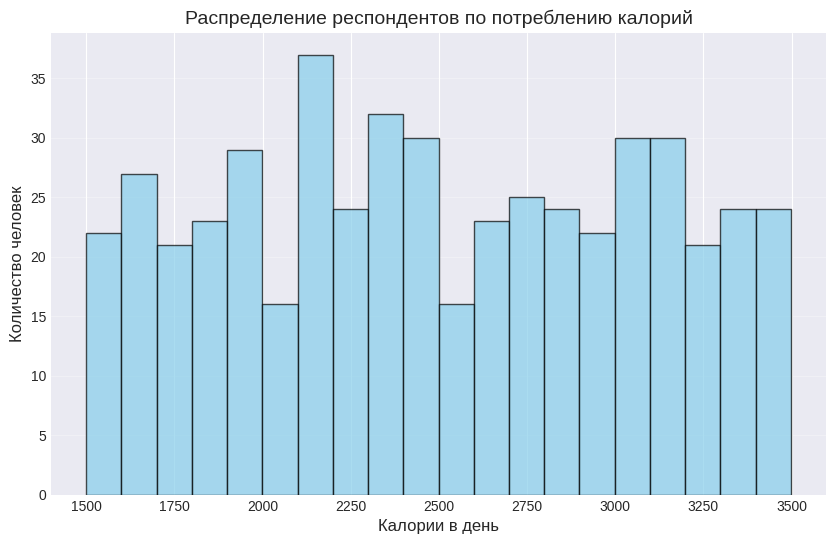

Всего опрошено: 500 человек
В среднем едят: 2499 ккал
Меньше всего: 1500 ккал
Больше всего: 3498 ккал


In [34]:
#Визуализируем распределение респондентов по объему потребленных калорий
# Подключаемся к базе
conn = sqlite3.connect('diabetes_analysis.db')

# Получаем данные
query = "SELECT daily_calorie_intake FROM diabetes_data;"
calories = pd.read_sql_query(query, conn)
conn.close()

# Строим простую гистограмму
plt.figure(figsize=(10, 6))
plt.hist(calories['daily_calorie_intake'], bins=20, color='skyblue',
         edgecolor='black', alpha=0.7)

plt.title('Распределение респондентов по потреблению калорий', fontsize=14)
plt.xlabel('Калории в день', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)  # Ось Y - количество людей
plt.grid(axis='y', alpha=0.3)

# Показываем значения
plt.show()

# Простая статистика
print(f"Всего опрошено: {len(calories)} человек")
print(f"В среднем едят: {calories['daily_calorie_intake'].mean():.0f} ккал")
print(f"Меньше всего: {calories['daily_calorie_intake'].min()} ккал")
print(f"Больше всего: {calories['daily_calorie_intake'].max()} ккал")

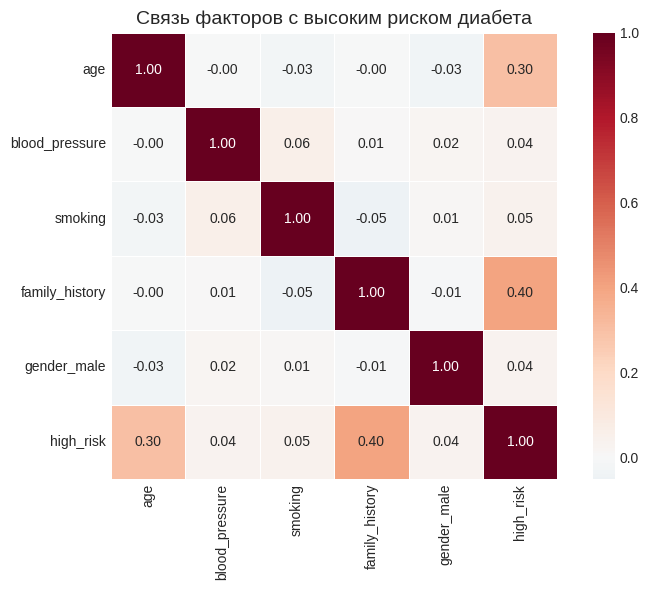

Влияние факторов на высокий риск диабета:
high_risk         1.000000
family_history    0.401311
age               0.302440
smoking           0.047977
gender_male       0.039812
blood_pressure    0.036416
Name: high_risk, dtype: float64


In [38]:
#Визуализируем зависимость между рядом критериев и высоким уровнем диабета
# Подключаемся к базе
conn = sqlite3.connect('diabetes_analysis.db')

# Получаем данные (превращаем текстовые поля в числа)
query = """
SELECT
    age,
    blood_pressure,
    CASE WHEN smoking_status = 'Current' THEN 2
         WHEN smoking_status = 'Former' THEN 1
         ELSE 0 END as smoking,
    CASE WHEN family_history_diabetes = 'Yes' THEN 1 ELSE 0 END as family_history,
    CASE WHEN gender = 'Male' THEN 1 ELSE 0 END as gender_male,
    CASE WHEN diabetes_risk_category IN ('High', 'Very High') THEN 1 ELSE 0 END as high_risk
FROM diabetes_data;
"""
df = pd.read_sql_query(query, conn)
conn.close()

# Рисуем тепловую карту
plt.figure(figsize=(8, 6))

# Считаем корреляции
corr = df.corr()

# Тепловая карта
sns.heatmap(corr,
            annot=True,           # показывать числа
            cmap='RdBu_r',        # красно-синяя цветовая схема
            center=0,              # центр в 0
            square=True,           # квадратные ячейки
            fmt='.2f',             # формат чисел
            linewidths=0.5)        # линии между ячейками

plt.title('Связь факторов с высоким риском диабета', fontsize=14)
plt.tight_layout()
plt.show()

# Смотрим только связь с риском
print("Влияние факторов на высокий риск диабета:")
print(corr['high_risk'].sort_values(ascending=False))


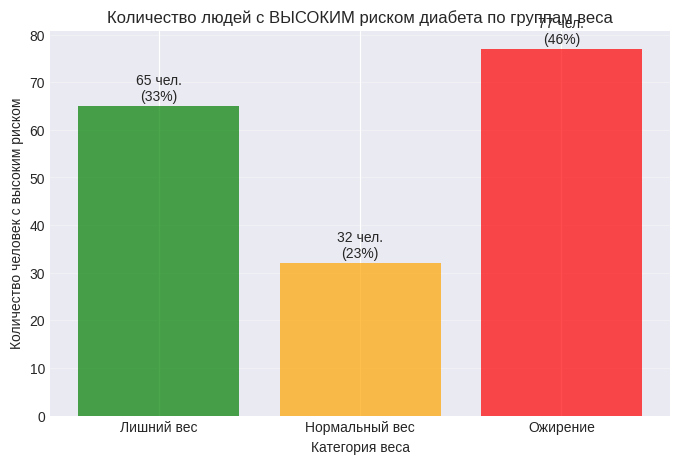

Статистика:
Лишний вес: 65 чел. с высоким риском из 197 всего (33%)
Нормальный вес: 32 чел. с высоким риском из 137 всего (23%)
Ожирение: 77 чел. с высоким риском из 166 всего (46%)


In [35]:
#визуализируем количество респондентов с высоким риском диабета в зависимости от bmi

# Подключаемся к базе
conn = sqlite3.connect('diabetes_analysis.db')
df = pd.read_sql_query("SELECT BMI, diabetes_risk_score, diabetes_risk_category FROM diabetes_data;", conn)
conn.close()

# Разбиваем на группы веса
def get_weight_group(bmi):
    if bmi < 25:
        return 'Нормальный вес'
    elif bmi < 30:
        return 'Лишний вес'
    else:
        return 'Ожирение'

df['weight_group'] = df['BMI'].apply(get_weight_group)

# Считаем количество людей с высоким риском в каждой группе
# Высокий риск - это категория 'High' или 'Very High'
high_risk = df[df['diabetes_risk_category'].isin(['High', 'Very High'])]
stats = high_risk.groupby('weight_group').size()

# Всего людей в каждой группе
total = df.groupby('weight_group').size()

# Рисуем
plt.figure(figsize=(8, 5))
bars = plt.bar(stats.index, stats.values, color=['green', 'orange', 'red'], alpha=0.7)

# Подписываем столбцы
for bar, group in zip(bars, stats.index):
    height = bar.get_height()
    percent = (height / total[group]) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)} чел.\n({percent:.0f}%)',
             ha='center', va='bottom')

plt.title('Количество людей с ВЫСОКИМ риском диабета по группам веса')
plt.xlabel('Категория веса')
plt.ylabel('Количество человек с высоким риском')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Выводим подробности
print("Статистика:")
for group in stats.index:
    print(f"{group}: {stats[group]} чел. с высоким риском из {total[group]} всего ({stats[group]/total[group]*100:.0f}%)")
